1. IMPORTS AND DATA LOADING

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
train = pd.read_csv("../data/train.csv")

2. EXPLORATORY DATA ANALYSIS (EDA)

2.1 Understanding the data


In [4]:
train.shape

(1460, 81)

In [5]:
train.head()
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


remove Id column - unnecessary for prediction model

In [6]:
train.drop(['Id'],axis=1,inplace=True)

2.2 Missing value Count and percentage

<Axes: >

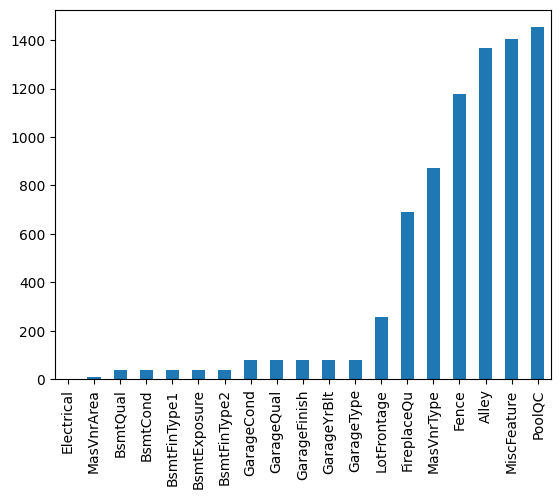

In [7]:
missing = train.isnull().sum()
missing= missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar()


In [8]:
miss_percent = (train.isnull().sum() / len(train)) * 100
miss_percent= miss_percent[miss_percent>0]
miss_percent=miss_percent.sort_values(ascending= False)
miss_percent

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

drop columns = PoolQC ,MiscFeature ,Alley ,Fence   more than 80% missing values


In [9]:
train.drop(['PoolQC','MiscFeature','Alley','Fence'],axis=1, inplace=True)

2.3 Histogram- SalePrice distribution


np.float64(1.8828757597682129)

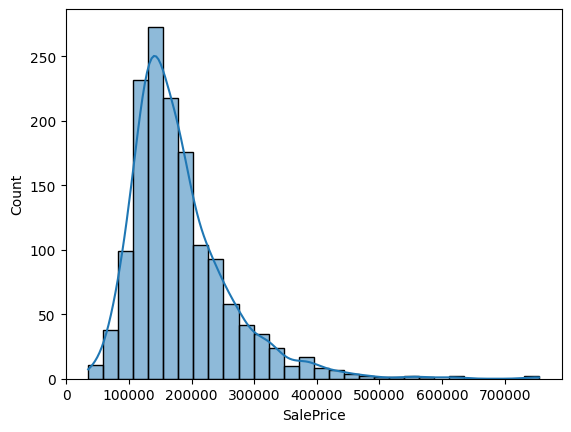

In [10]:
sns.histplot(train['SalePrice'], kde= True ,bins=30)
train['SalePrice'].skew()

positive skewness- right skewed 
so we use log(x) to make it more normally distributed

In [11]:
train['SalePrice'] = np.log1p(train['SalePrice'])
train['SalePrice'].skew()

np.float64(0.12134661989685329)

<Axes: xlabel='SalePrice', ylabel='Count'>

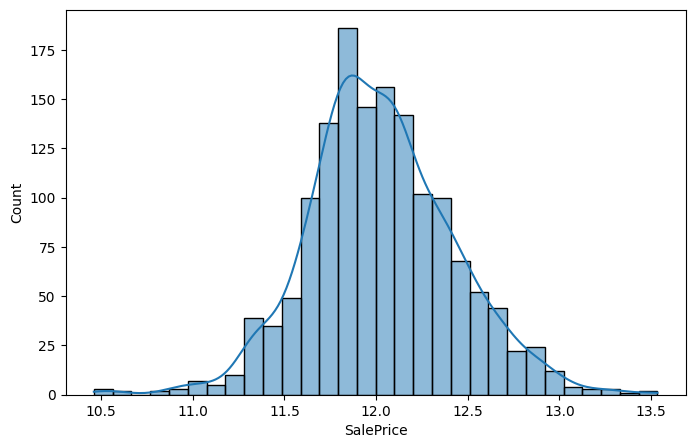

In [12]:
plt.figure(figsize=(8, 5))    # small
sns.histplot(train['SalePrice'], kde= True ,bins=30)

In [13]:
train['SalePrice'].describe()

count    1460.000000
mean       12.024057
std         0.399449
min        10.460271
25%        11.775105
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice, dtype: float64

The distribution of SalePrice is positively skewed, indicating the presence of a small number of very expensive houses. Applying a log transformation (log1p) results in a distribution that is closer to normal, which can improve the performance of regression models.

2.4 Numerical and Categorical Values

In [14]:
nums = train.select_dtypes(include=[np.number])
nums.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

In [15]:
catg = train.select_dtypes(include=[object])
catg.columns

/var/folders/zq/8j1g8nx571l4jtmw_t1d4njw0000gn/T/ipykernel_41244/2296717657.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catg = train.select_dtypes(include=[object])


Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='str')

CORRELATION ANALYSIS - NUMERICAL VALUE ANALYSIS

In [16]:
corr = nums.corr()
print(corr['SalePrice'].sort_values(ascending=False),'\n')


SalePrice        1.000000
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
GarageYrBlt      0.541073
TotRmsAbvGrd     0.534422
Fireplaces       0.489450
MasVnrArea       0.430809
BsmtFinSF1       0.372023
LotFrontage      0.355879
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209043
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057330
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
Name: SalePrice, dtype: float64 



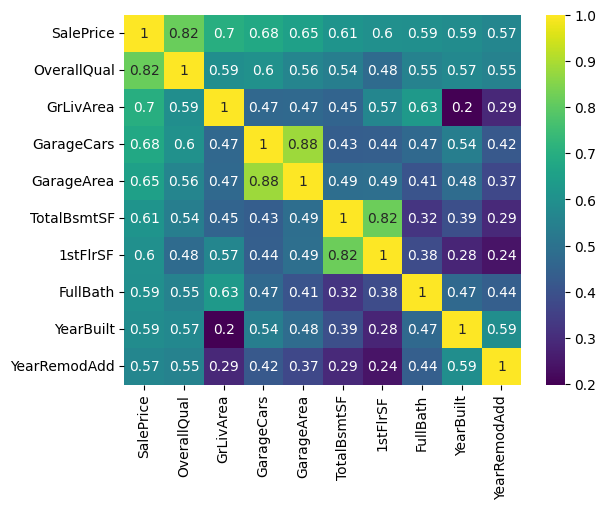

In [17]:
top_cols= corr['SalePrice'].sort_values(ascending=False).head(10).index

sns.heatmap(
    train[top_cols].corr(),
    annot=True,
    cmap="viridis"
)
plt.show()

Multicollinearity- when two or more independent variables are highly correlated with each other and the target variable

eg- GarageArea and GarageCars (0.88)  |r| > 0.8
so we remove GarageArea 

2.5 Scatterplots

<Axes: xlabel='WoodDeckSF', ylabel='SalePrice'>

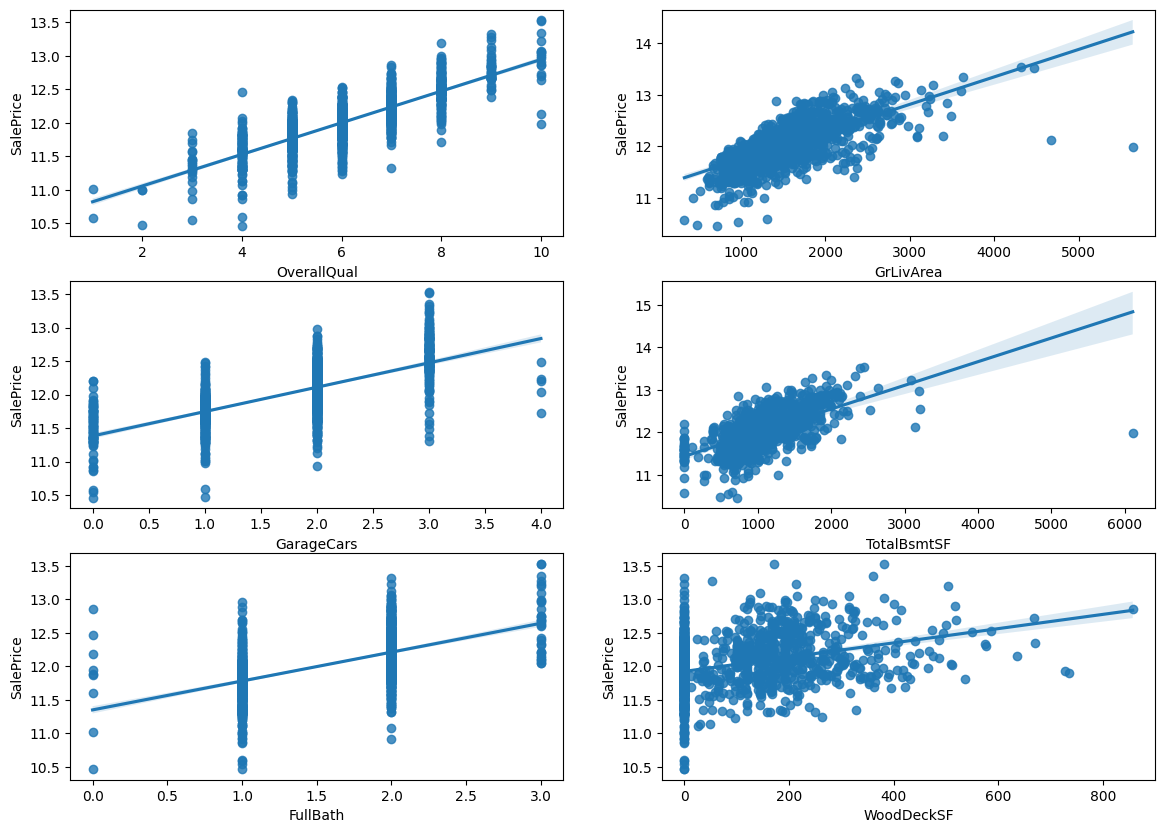

In [18]:
fig, ((ax1,ax2),(ax3,ax4),(ax5,ax6))= plt.subplots(nrows=3, ncols=2, figsize=(14,10))
sns.regplot(x='OverallQual',y='SalePrice',data= train,scatter=True, fit_reg=True,ax= ax1)
sns.regplot(x='GrLivArea',y='SalePrice',data= train,scatter=True, fit_reg=True,ax= ax2)
sns.regplot(x='GarageCars',y='SalePrice',data= train,scatter=True, fit_reg=True,ax= ax3)
sns.regplot(x='TotalBsmtSF',y='SalePrice',data= train,scatter=True, fit_reg=True,ax= ax4)
sns.regplot(x='FullBath',y='SalePrice',data= train,scatter=True, fit_reg=True,ax= ax5)
sns.regplot(x='WoodDeckSF',y='SalePrice',data= train,scatter=True, fit_reg=True,ax= ax6)


Regression plots indicate strong positive relationships between SalePrice and OverallQual, GrLivArea, GarageCars, and TotalBsmtSF. Among these, OverallQual and GrLivArea appear to be the most influential features. FullBath shows a moderate positive relationship, while WoodDeckSF exhibits a weaker correlation. A few potential outliers are visible in the GrLivArea and TotalBsmtSF plots and may require further investigation.



2.6 Outliners

In [19]:
train[
    (train['GrLivArea'] > 4000) &
    (train['SalePrice'] < 12.3)
]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,60,RL,130.0,40094,Pave,IR1,Bnk,AllPub,Inside,Gtl,...,0,0,0,0,0,10,2007,New,Partial,12.126764
1298,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,Gtl,...,0,0,0,480,0,1,2008,New,Partial,11.982935


In [20]:
train= train.drop(
    train[(
        (train['GrLivArea']>4000)&
        (train['SalePrice']<12.3)
    )].index
)

In [21]:
train = train.drop(
    train[train['GrLivArea'] > 5000].index
)

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

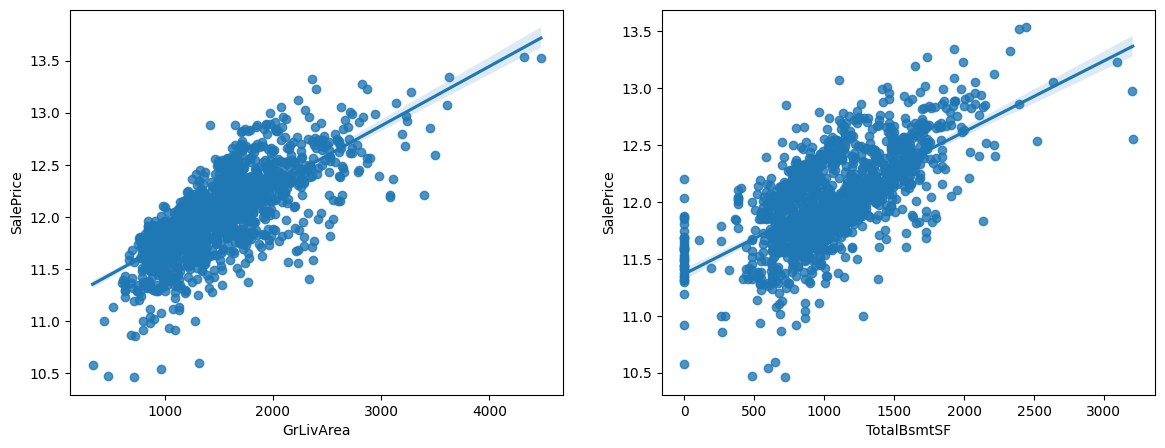

In [22]:
fix, (ax2,ax4)= plt.subplots(nrows=1 , ncols=2, figsize= (14,5))
sns.regplot(x='GrLivArea',y='SalePrice',data= train,scatter=True, fit_reg=True,ax= ax2)
sns.regplot(x='TotalBsmtSF',y='SalePrice',data= train,scatter=True, fit_reg=True,ax= ax4)

2.7 Categorical value analysis - BoxPlots

In [23]:
catg.columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='str')

Neighborhood, KitchenQual ,ExterQual ,BsmtQual, GarageType,MSZoning highly affecting categorical values (Location, Quality, Zoning, Construction) - drive the house price

<Axes: xlabel='Neighborhood', ylabel='SalePrice'>

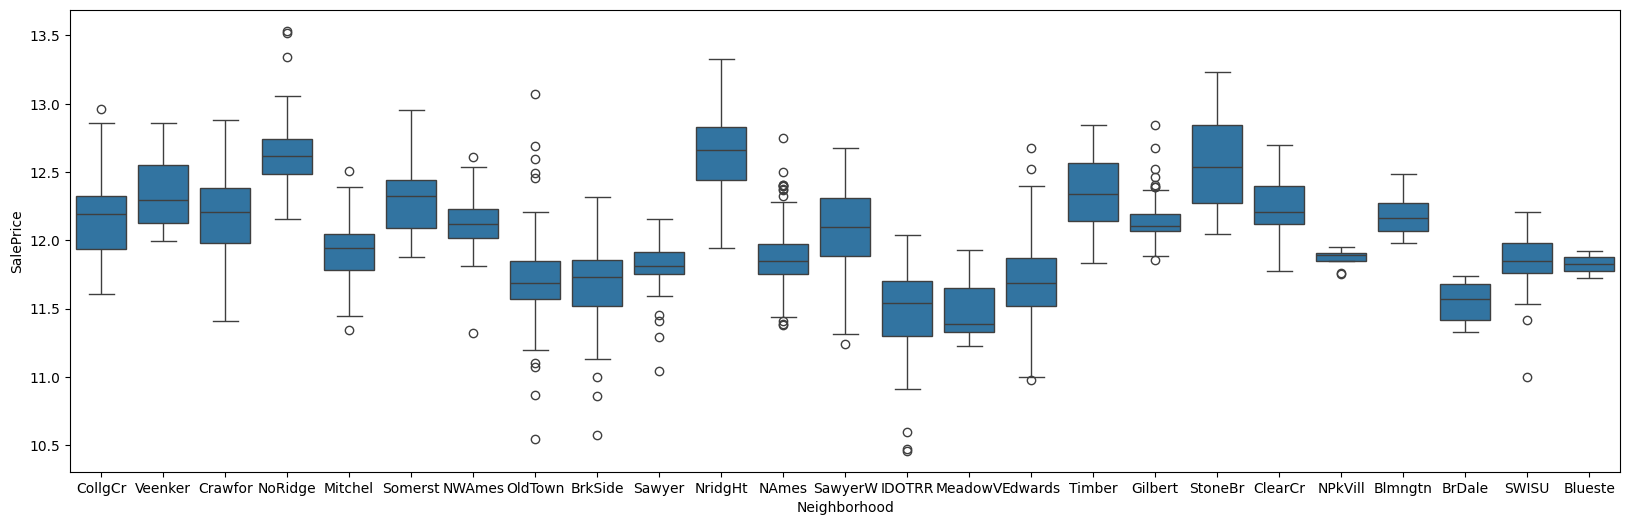

In [24]:
plt.figure(figsize=(20,6))
sns.boxplot(x='Neighborhood', y='SalePrice', data= train)

<Axes: xlabel='MSZoning', ylabel='SalePrice'>

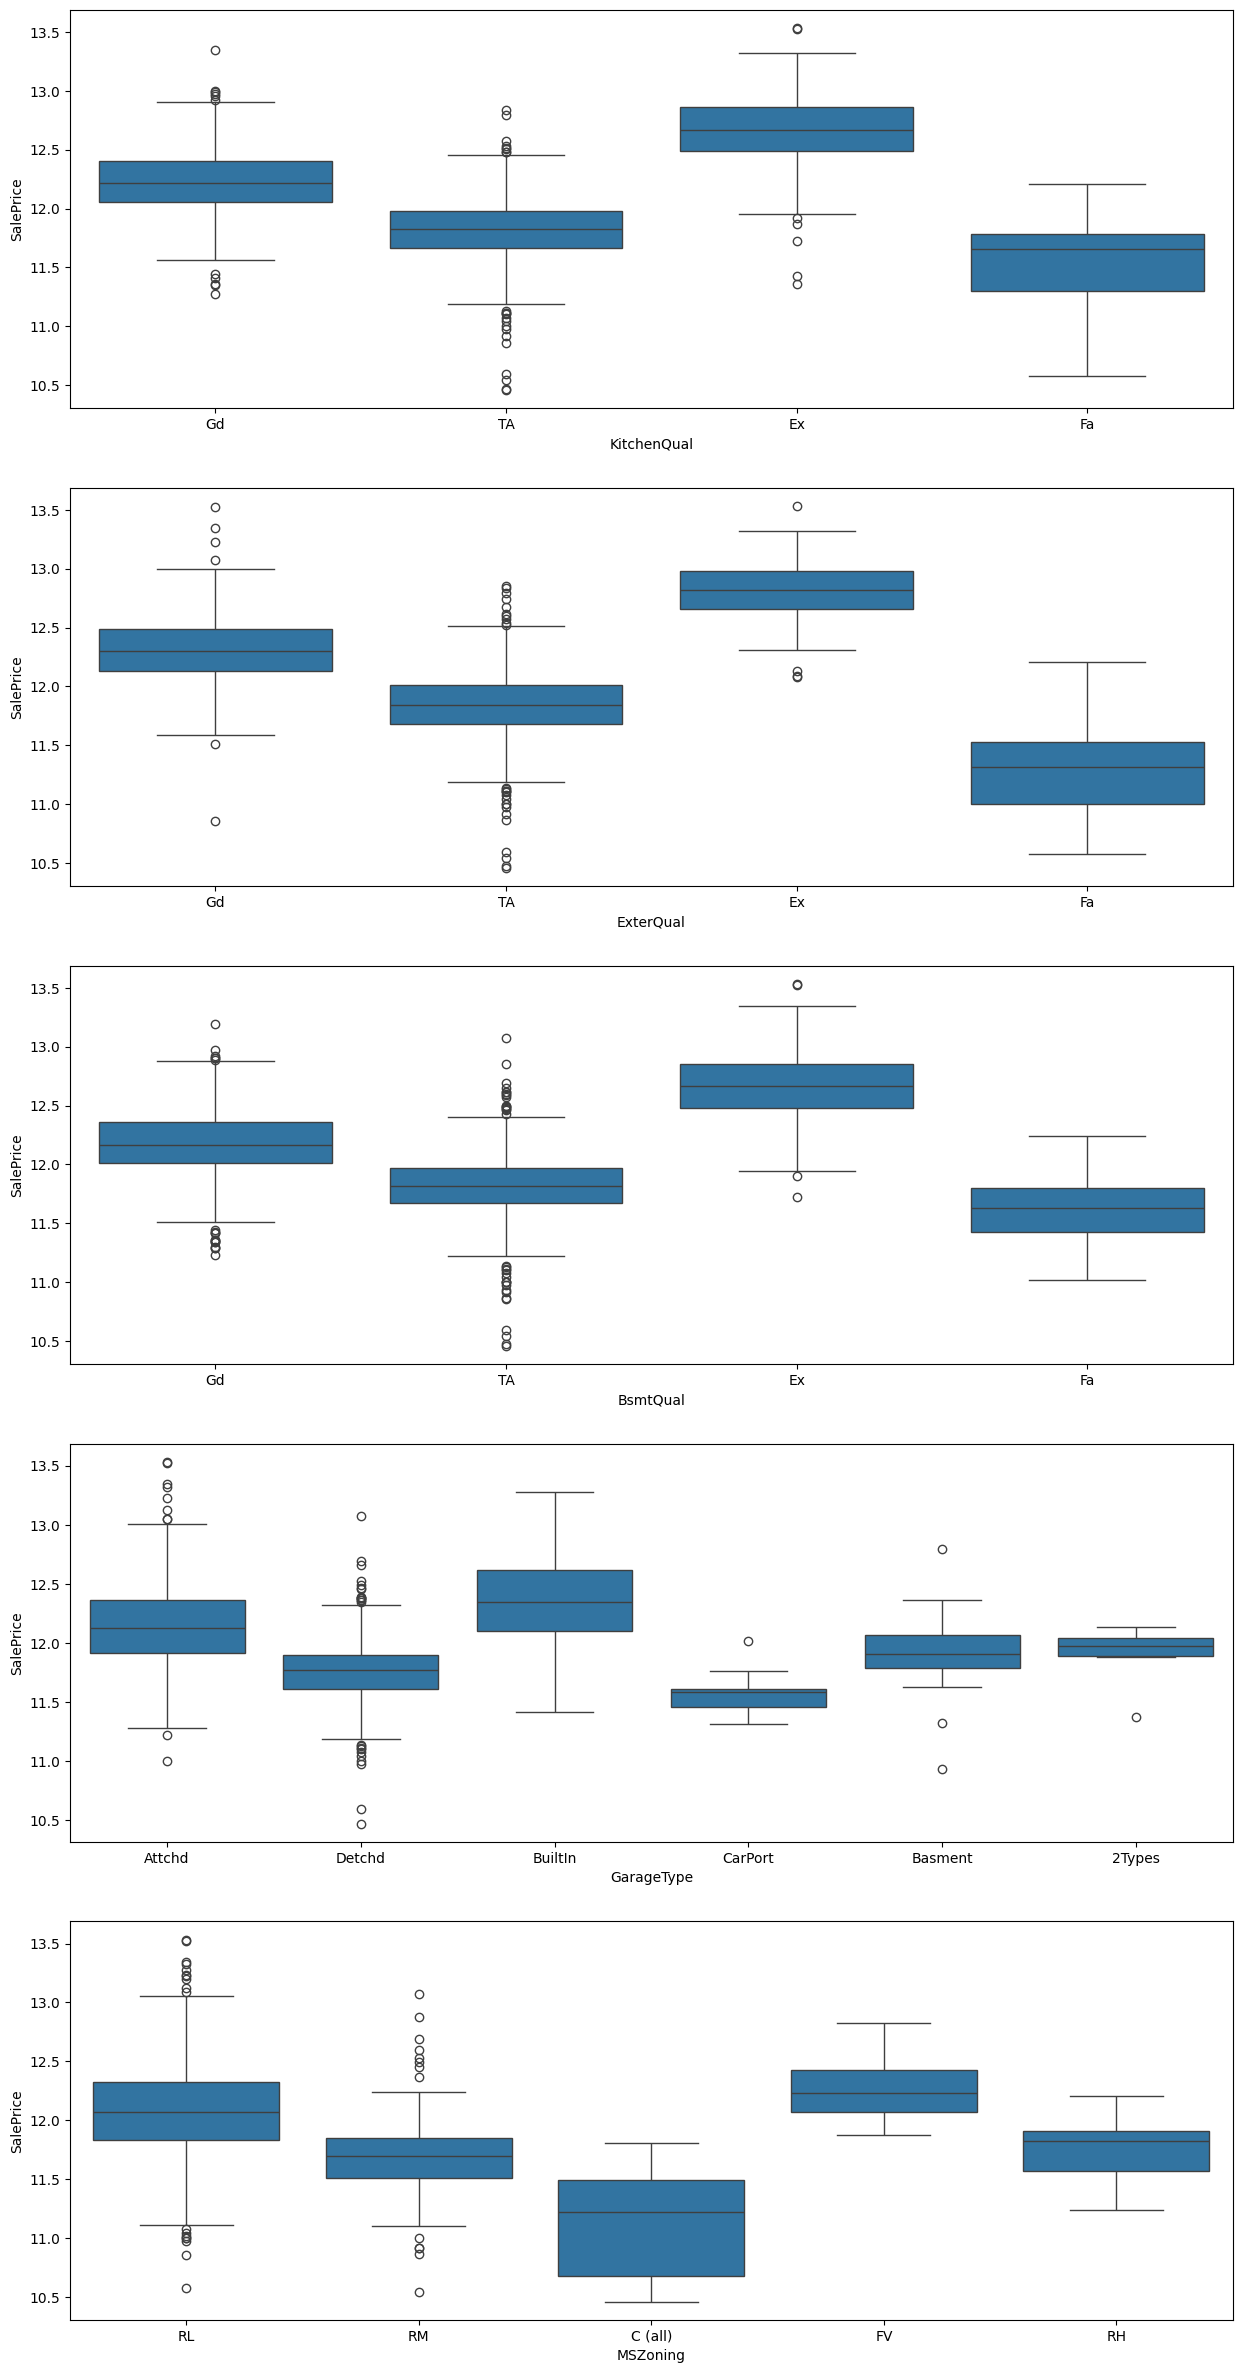

In [25]:
fig, ((ax2,ax3,ax4,ax5,ax6))= plt.subplots(nrows=5, ncols=1, figsize=(15,30))
sns.boxplot(x='KitchenQual', y='SalePrice', data= train, ax=ax2)
sns.boxplot(x='ExterQual', y='SalePrice', data= train, ax=ax3)
sns.boxplot(x='BsmtQual', y='SalePrice', data= train, ax=ax4)
sns.boxplot(x='GarageType', y='SalePrice', data= train,ax=ax5)
sns.boxplot(x='MSZoning', y='SalePrice', data= train, ax=ax6)

Neighborhood, KitchenQual ,ExterQual ,BsmtQual - high effect
GarageType,MSZoning- moderate effect

3. DATA CLEANING AND PREPROCESSING

3.1 Missing Value Handling

we've already dropped missing values >80% 

In [26]:
missing_pct = (train.isnull().sum()/len(train))*100
missing_pct = missing_pct[missing_pct > 0]
missing_pct.sort_values(ascending=False)

MasVnrType      59.807956
FireplaceQu     47.325103
LotFrontage     17.764060
GarageType       5.555556
GarageYrBlt      5.555556
GarageFinish     5.555556
GarageQual       5.555556
GarageCond       5.555556
BsmtExposure     2.606310
BsmtFinType2     2.606310
BsmtQual         2.537723
BsmtCond         2.537723
BsmtFinType1     2.537723
MasVnrArea       0.548697
Electrical       0.068587
dtype: float64

In [27]:
train['MasVnrType'].value_counts(dropna=False)

MasVnrType
NaN        872
BrkFace    445
Stone      126
BrkCmn      15
Name: count, dtype: int64

In [28]:
train['MasVnrType'] = train['MasVnrType'].fillna('None')

In [29]:
train['MasVnrType'].value_counts(dropna=False)

MasVnrType
None       872
BrkFace    445
Stone      126
BrkCmn      15
Name: count, dtype: int64

In [30]:
train['LotFrontage'] = train['LotFrontage'].fillna(
    train['LotFrontage'].median()
)

In [31]:
train['FireplaceQu'] = train['FireplaceQu'].fillna('None')

In [32]:
#no garage - categorical columns
garage_cols = [
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond'
]

for col in garage_cols:
    train[col] = train[col].fillna('None')

In [33]:
#numerical garage colums we use median
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(
    train['GarageYrBlt'].median()
)

In [34]:
#no basement
bsmt_cols = [
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2'
]

for col in bsmt_cols:
    train[col] = train[col].fillna('None')


In [35]:
train['MasVnrArea'] = train['MasVnrArea'].fillna(
    train['MasVnrArea'].median()
)

In [36]:
#non numerical so we fill the 1 empty space w most occuring value
train['Electrical'] = train['Electrical'].fillna(
    train['Electrical'].mode()[0]
)

In [37]:
train.isnull().sum().sum() == 0

np.True_

4. FEATURE ENGINEERING

we convert raw features into Business Meaning

In [38]:
train.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF'

In [39]:
train['TotalSF']=(train['TotalBsmtSF']+train['1stFlrSF']+train['2ndFlrSF'])

In [40]:
train['HouseAge']= (train['YrSold']-train['YearBuilt'])

In [41]:
train['YearsSinceRemodel']= (train['YrSold']- train['YearRemodAdd'])

In [42]:
train['TotalBathrooms']=(train['FullBath'])+0.5*train['HalfBath']+ train['BsmtFullBath']+ 0.5 * train['BsmtHalfBath']

In [43]:
train['TotalPorchSF']=(train['OpenPorchSF']+train['EnclosedPorch']+train['3SsnPorch']+train['ScreenPorch'])

In [44]:
train[['TotalSF','HouseAge','YearsSinceRemodel','TotalBathrooms','TotalPorchSF']].head()

,TotalSF,HouseAge,YearsSinceRemodel,TotalBathrooms,TotalPorchSF
0,2566,5,5,3.5,61
1,2524,31,31,2.5,0
2,2706,7,6,3.5,42
3,2473,91,36,2.0,307
4,3343,8,8,3.5,84


In [45]:
new_features = [
    'TotalSF',
    'HouseAge',
    'YearsSinceRemodel',
    'TotalBathrooms',
    'TotalPorchSF'
]

train[new_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)

SalePrice            1.000000
TotalSF              0.825326
TotalBathrooms       0.676678
TotalPorchSF         0.195648
YearsSinceRemodel   -0.568529
HouseAge            -0.587767
Name: SalePrice, dtype: float64

TotalPorchSF         0.195167 - weak relationship

5. ENCODING

In [46]:
cat_cols = train.select_dtypes(include=object).columns

print(len(cat_cols))
print(cat_cols.tolist())

39
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


/var/folders/zq/8j1g8nx571l4jtmw_t1d4njw0000gn/T/ipykernel_41244/2895553922.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include=object).columns


In [47]:
X = train.drop('SalePrice', axis=1)
Y = train['SalePrice']

print(X.shape)
print(Y.shape)

(1458, 80)
(1458,)


In [48]:
X = pd.get_dummies(X, drop_first=True)
print(X.shape)

(1458, 250)


6. TRAIN/ TEST SPLIT

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_valid, Y_train,Y_valid = train_test_split(
    X,
    Y,
    test_size= 0.2,
    random_state=40
    )

In [50]:
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", Y_train.shape)
print("y_valid:", Y_valid.shape)

X_train: (1166, 250)
X_valid: (292, 250)
y_train: (1166,)
y_valid: (292,)


Train Set - X_train | 
Validation Set - X_valid | 
Test Set -  test.csv | 

7. LINEAR REGRESSION(Baseline Model)

In [51]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
lr.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](250,)","[-0. , 0. , 0. ,...,-0.01, 0.07, 0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](250,)","['MSSubClass','LotFrontage','LotArea',...,'SaleCondition_Family', 'SaleCondition_Normal','SaleCondition_Partial']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.987
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,250
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,231


In [52]:
Y_pred= lr.predict(X_valid)

In [53]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
rmse = root_mean_squared_error(  Y_valid, Y_pred)
mae= mean_absolute_error( Y_valid, Y_pred)
r2= r2_score(Y_valid, Y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

RMSE: 0.11522933554930102
MAE : 0.08080831514160465
R²  : 0.9092676288613895


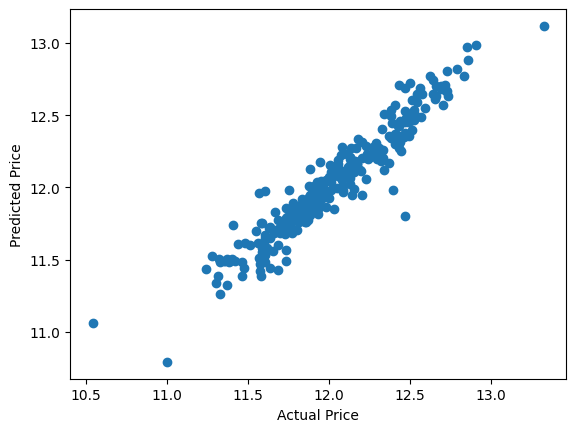

In [54]:
plt.scatter( Y_valid, Y_pred )
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

8. RANDOM FOREST MODEL

combines predictions from multiple decision trees. Each tree is trained on a random subset of the training data and features, and the final prediction is obtained by averaging the outputs of all trees.


In [55]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor (
    n_estimators= 300,
    random_state=42,
    n_jobs= 1
)

rf.fit(X_train,Y_train)
Y_pred= rf.predict(X_valid)

rmse= root_mean_squared_error(Y_valid,Y_pred)
mae= mean_absolute_error(Y_valid,Y_pred)
r2= r2_score(Y_valid,Y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)


RMSE: 0.1233385249071511
MAE : 0.087125001148651
R²  : 0.8960478094409302


Linear Regressing has a better value that Random forest due to the preprocessing.

9. XGBoost

In [56]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, Y_train)
y_pred = xgb.predict(X_valid)

rmse= root_mean_squared_error(Y_valid,Y_pred)
mae= mean_absolute_error(Y_valid,Y_pred)
r2= r2_score(Y_valid,Y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

RMSE: 0.1233385249071511
MAE : 0.087125001148651
R²  : 0.8960478094409302


10. CROSS VALIDATION

In [58]:
from sklearn.model_selection import cross_val_score

linearCV = -cross_val_score(
    lr,
    X,
    Y,
    scoring='neg_root_mean_squared_error',
    cv=10
)
forestCV = -cross_val_score(
    rf,
    X,
    Y,
    scoring='neg_root_mean_squared_error',
    cv=10
)
boostCV = -cross_val_score(
    xgb,
    X,
    Y,
    scoring='neg_root_mean_squared_error',
    cv=10
)


print("Mean linear:", linearCV.mean())
print("Mean randomForest:", forestCV.mean())
print("Mean XGboost:", boostCV.mean())


Mean linear: 0.11983138943940261
Mean randomForest: 0.13597190909034212
Mean XGboost: 0.11652106800275497


11. HYPERPARAMETER TUNING 

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# Base model
xgb = XGBRegressor( random_state=42)

# Hyperparameter search space
param_grid = {
    'n_estimators': [200, 500,800, 1000],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator= xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train
random_search.fit(X_train, Y_train)

# Best results
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)

In [67]:
best_xgb = XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    
)
best_xgb.fit(X_train, Y_train)
y_pred = best_xgb.predict(X_valid)

rmse = root_mean_squared_error(Y_valid, y_pred)
mae = mean_absolute_error(Y_valid, y_pred)
r2 = r2_score(Y_valid, y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

RMSE: 0.10186296124917239
MAE : 0.071994079121874
R²  : 0.9290963259041654


I started with a Linear Regression baseline, then evaluated Random Forest and XGBoost models. After comparing models using cross-validation, I applied RandomizedSearchCV to tune XGBoost hyperparameters such as learning rate, tree depth, number of estimators, subsampling ratio, and column sampling ratio. The tuned XGBoost model improved performance from an R² of approximately 0.91 to 0.93 while reducing RMSE from 0.115 to 0.102.


In [69]:
# Convert back to dollars
y_valid_dollar = np.expm1(Y_valid)
y_pred_dollar = np.expm1(y_pred)

rmse = root_mean_squared_error(
    y_valid_dollar,
    y_pred_dollar
)
print(f"RMSE: ${rmse:,.2f}")

RMSE: $18,360.14


BEST MODEL - XGBoost(tuned)

- **RMSE**: $18,360.14

- **R²**  : 0.9290963259041654

12. MODEL EVALUATION & RESULTS

Validation Set Performance

| Model | RMSE ↓ | MAE ↓ | R² ↑ |
|--------|---------:|---------:|---------:|
| Linear Regression | 0.1152 | 0.0808 | 0.9093 |
| Random Forest | 0.1237 | 0.0870 | 0.8954 |
| XGBoost | 0.1233 | 0.0871 | 0.8960 |
| **Tuned XGBoost** | **0.1019** | **0.0720** | **0.9291** |

10-Fold Cross-Validation Performance

| Model | Mean RMSE ↓ |
|--------|---------:|
| Linear Regression | 0.1198 |
| Random Forest | 0.1360 |
| **XGBoost** | **0.1165** |

<br>

| Selected Model | Validation RMSE | Validation R² |
|----------------|----------------:|--------------:|
| **Tuned XGBoost** | **0.1019** | **0.9291** |



**CONCLUSION:** 

XGBoost achieved the best overall performance, obtaining the lowest cross-validation RMSE (0.1165). After hyperparameter tuning with RandomizedSearchCV, the final model achieved a validation RMSE of 0.1019 and R² of 0.9291.